# Lab 9
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.

In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


ensure_module('numpy', ['numpy<2'])
ensure_module('matplotlib', ['matplotlib'])
ensure_module('PIL', ['Pillow'])
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')

numpy already available.


matplotlib already available.
PIL already available.


cv2 already available.
skimage already available.
Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Task 1: Erosion
Erosion shrinks bright (foreground) regions by sliding a structuring element across the image. A pixel is kept only if the entire kernel fits inside the foreground. Larger kernels produce more aggressive erosion.

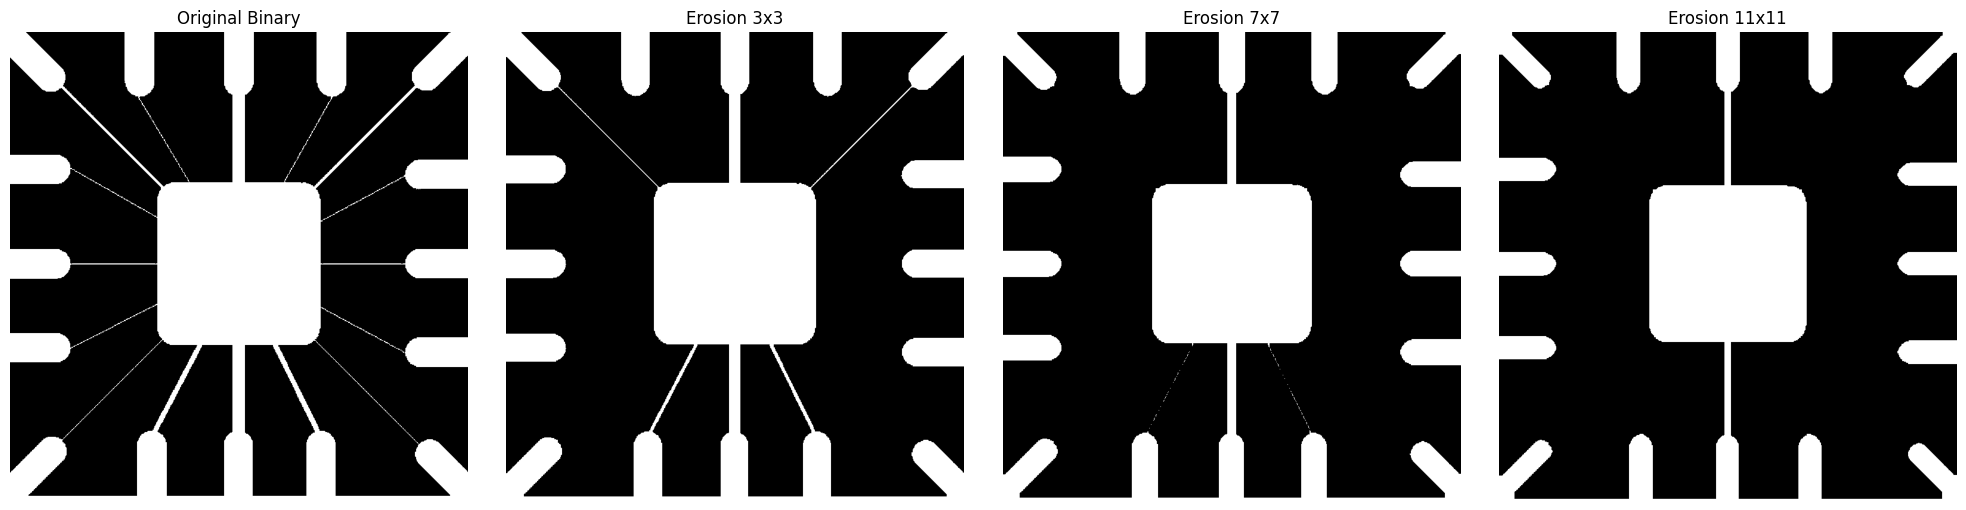

In [3]:
img = cv2.imread(str(IMAGES_DIR / 'Erosion.jpg'), 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

eroded3 = cv2.erode(binary, kernel3, iterations=1)
eroded7 = cv2.erode(binary, kernel7, iterations=1)
eroded11 = cv2.erode(binary, kernel11, iterations=1)

show_images(
    [binary, eroded3, eroded7, eroded11],
    ['Original Binary', 'Erosion 3x3', 'Erosion 7x7', 'Erosion 11x11'],
    figsize=(20, 5)
)

### Task 2: Dilation
Dilation expands bright regions. A pixel becomes foreground if *any* part of the kernel overlaps a foreground pixel. It is the dual of erosion.

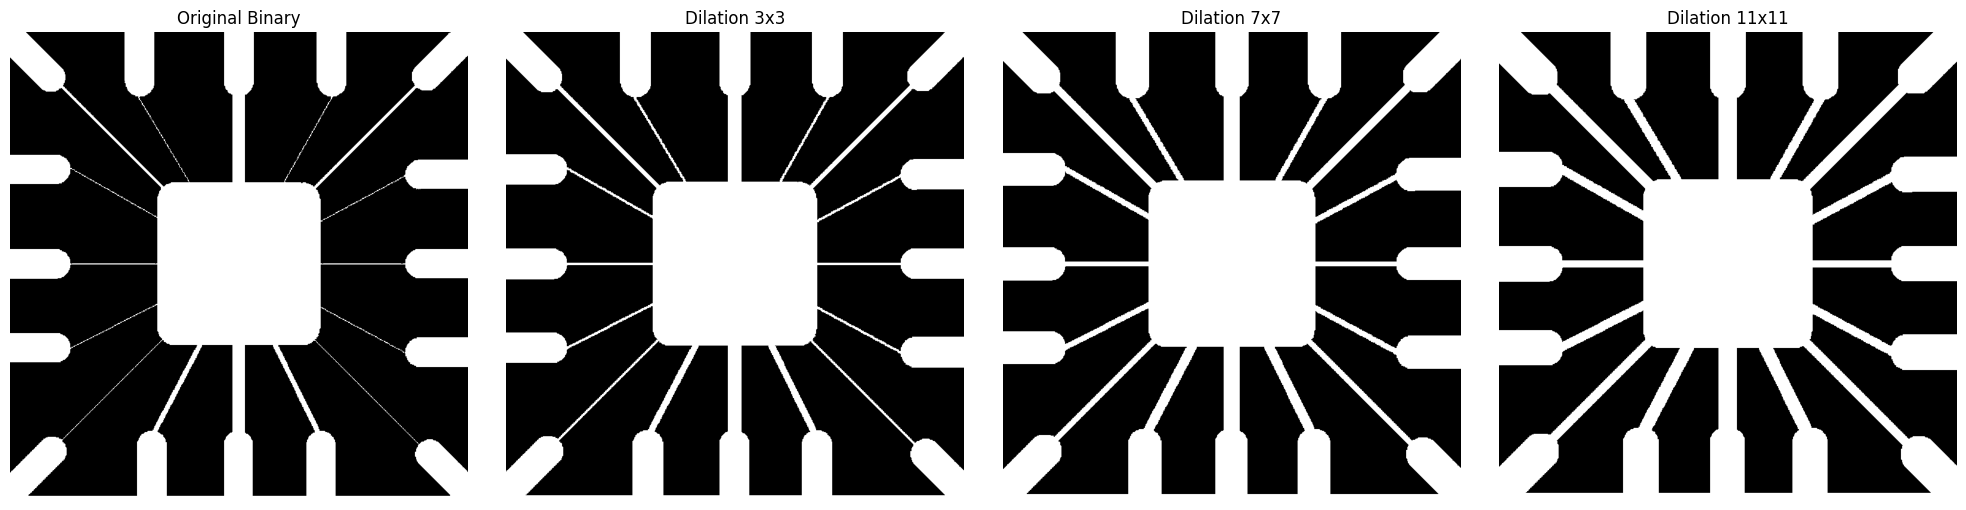

In [4]:
img = cv2.imread(str(IMAGES_DIR / 'Erosion.jpg'), 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel11 = np.ones((11, 11), np.uint8)

dilated3 = cv2.dilate(binary, kernel3, iterations=1)
dilated7 = cv2.dilate(binary, kernel7, iterations=1)
dilated11 = cv2.dilate(binary, kernel11, iterations=1)

show_images(
    [binary, dilated3, dilated7, dilated11],
    ['Original Binary', 'Dilation 3x3', 'Dilation 7x7', 'Dilation 11x11'],
    figsize=(20, 5)
)

### Task 3: Opening
Opening = erosion followed by dilation. It removes small bright noise while preserving the overall shape of larger objects.

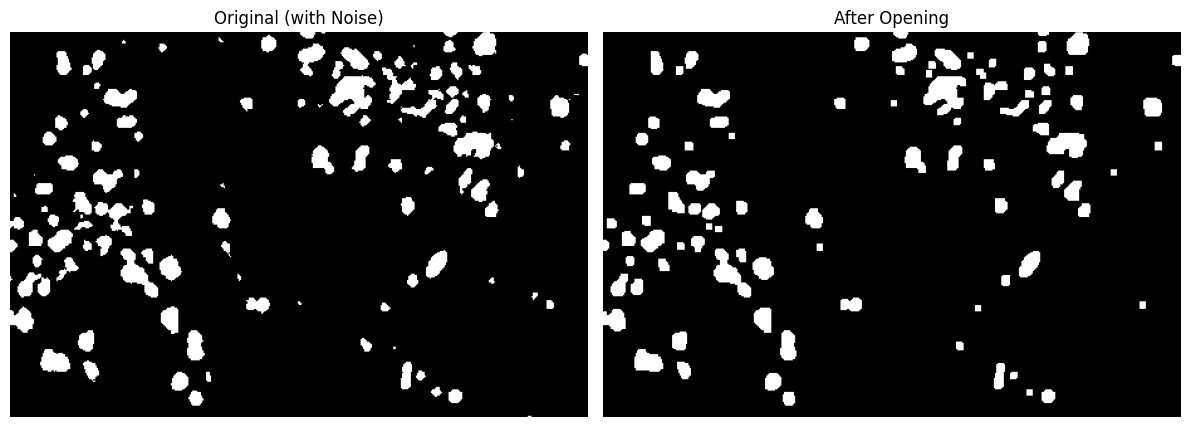

In [5]:
img = cv2.imread(str(IMAGES_DIR / 'Open_Closing.jpg'), 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

show_images(
    [binary, opening],
    ['Original (with Noise)', 'After Opening'],
    figsize=(12, 5)
)

### Task 4: Closing
Closing = dilation followed by erosion. It fills small dark holes inside foreground objects while keeping the overall shape.

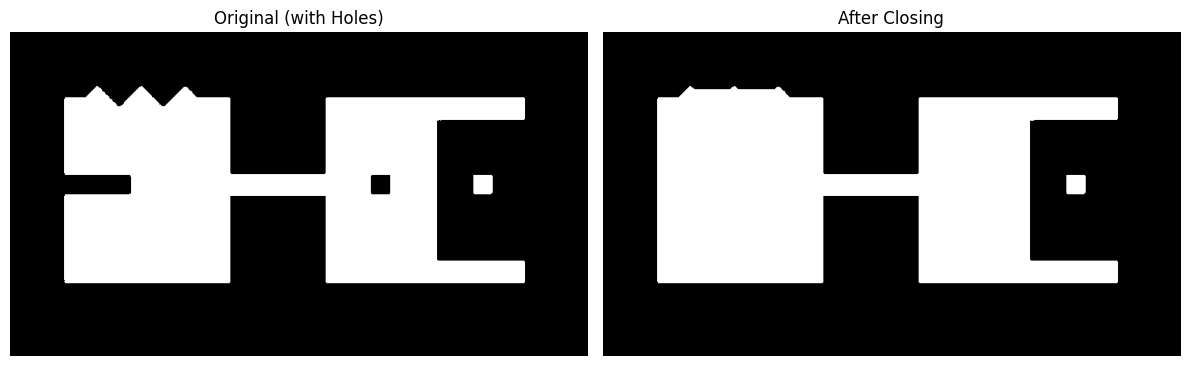

In [6]:
img = cv2.imread(str(IMAGES_DIR / 'Opening2.jpg'), 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((45, 45), np.uint8)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

show_images(
    [binary, closing],
    ['Original (with Holes)', 'After Closing'],
    figsize=(12, 5)
)

### Task 5: Boundary Extraction
Boundaries can be extracted using morphological operations:
- **Gradient**: dilation − erosion (full boundary)
- **Internal**: original − eroded (inner boundary)
- **External**: dilated − original (outer boundary)

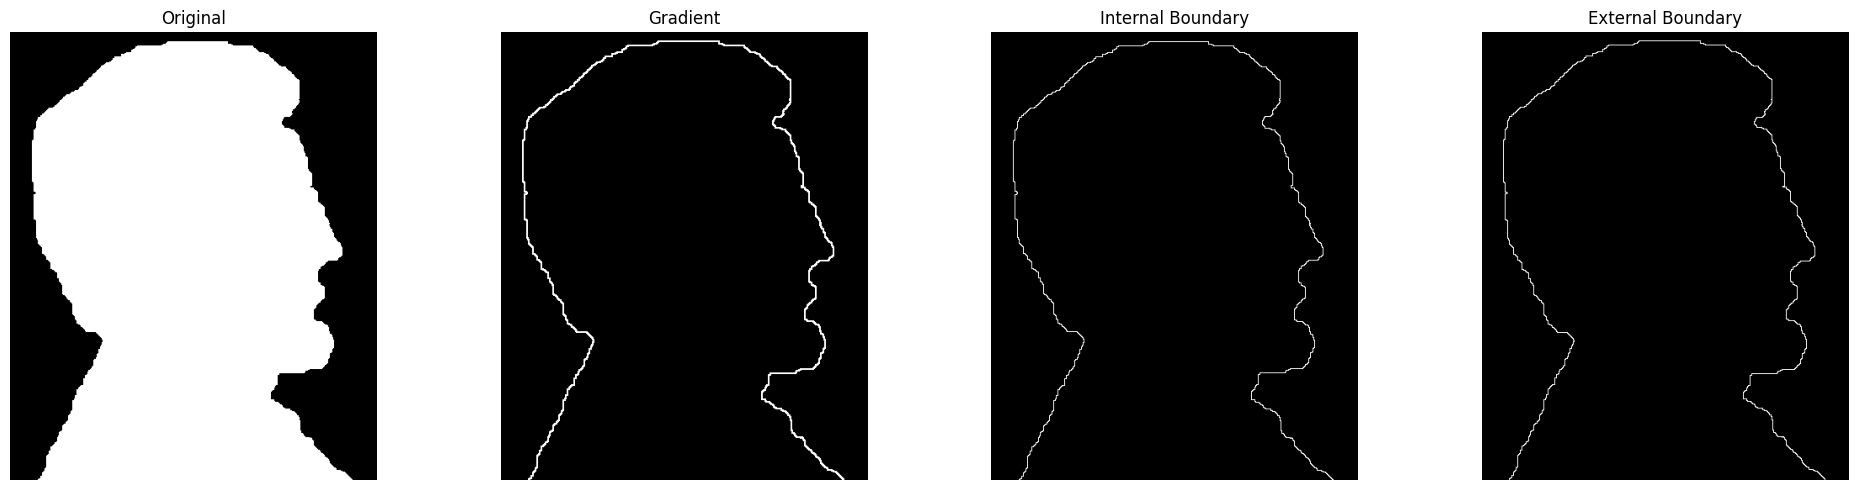

In [7]:
img = cv2.imread(str(IMAGES_DIR / 'BoundaryExtraction.jpg'), 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)

gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

eroded = cv2.erode(binary, kernel)
internal = cv2.subtract(binary, eroded)

dilated = cv2.dilate(binary, kernel)
external = cv2.subtract(dilated, binary)

show_images(
    [binary, gradient, internal, external],
    ['Original', 'Gradient', 'Internal Boundary', 'External Boundary'],
    figsize=(20, 5)
)